# Temporal Feature Engineering

For the past five lessons, we have been living in the world of Classical Statistics. Algorithms like Exponential Smoothing and ARIMA possess an internal clock. They natively understand the mathematical sequence of $t$, $t-1$, and $t-2$.

But Classical Statistics has a massive limitation: it struggles to incorporate dozens of external variables (like weather, marketing spend, or regional demographics) simultaneously.

To achieve maximum enterprise accuracy, we often want to unleash modern Machine Learning algorithms (like XGBoost, LightGBM, or Random Forests) on our temporal data. However, **Machine Learning algorithms are entirely time-blind.** If you hand XGBoost a time series, it assumes row 10 and row 1,000 are completely independent.

To fix this, we must translate "Time" into "Tabular Columns." We must build a Feature Matrix ($X$). In this lesson, we will surgically extract the hidden context of the calendar.

Temporal Feature Engineering is the process of extracting mathematical signals from a raw Timestamp column. We are not looking at the target variable ($y$) yet; we are strictly extracting the context of *when* an event occurred.

Let's set up our Python environment to slice open the calendar.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Temporal Matrix Engineering Environment Ready.")

✅ Temporal Matrix Engineering Environment Ready.


# 1. Date and Time Extraction (The Baseline)

A raw timestamp like `2023-11-24 08:30:00` is incredibly dense. It contains the season, the day of the week, the time of day, and the quarter of the year. If we do not explicitly extract these components into separate columns, an algorithm like a Random Forest will never understand that traffic spikes every Friday.

We use `pandas` datetime attributes to split the single column into a wide matrix:

* **Categorical/Ordinal Time**: `Month` (1-12), `DayOfWeek` (0-6), `Quarter` (1-4), `Hour` (0-23).
* **Boolean Context**: `Is_Weekend` (0 or 1), `Is_Month_End` (0 or 1).

# 2. The Cyclic Boundary Problem (Trigonometric Encoding)

Extracting the `Month` as an integer from $1$ to $12$ introduces a catastrophic mathematical lie into our dataset.

If we encode December as $12$ and January as $1$, an algorithm calculating geometric distance (like a Support Vector Machine, K-Means, or a Neural Network) will see a massive gap of $11$ between them. It will assume December and January are the two furthest possible months apart.

In reality, December 31st and January 1st are separated by a single day. The calendar is a circle, not a straight line.

To fix this, we use **Trigonometric Encoding**. We project the linear timeline onto a 2D circle using Sine and Cosine transformations.


$$X_{sin} = \sin\left(\frac{2 \pi x}{\max(x)}\right)$$

$$X_{cos} = \cos\left(\frac{2 \pi x}{\max(x)}\right)$$

By using *both* Sine and Cosine together, every single month receives a unique 2D coordinate on a circle, and December perfectly connects back to January with a distance of exactly $1$ month!

# 3. Holiday and Event Proximity (The Gravity of Events)

Holidays (like New Year's Day) are massive outliers in enterprise data.
However, simply creating a Boolean column like `Is_NewYearsDay` (1 or 0) is usually insufficient.

Consumer behavior is altered by the *gravity* of an event. People start buying 30 days before New Year's Day. They return items 5 days after New Year's Day. To capture this temporal gravity, we must engineer **Distance Features**:

* `Days_Until_Holiday`
* `Days_Since_Promotion`

# 4. Building the Feature Matrix in Code

Let's simulate a raw timestamp dataset and engineer a robust, machine-learning-ready $X$ matrix, complete with trigonometric cycles and event distances.

In [2]:
# 1. Simulate a raw enterprise dataset with a single Timestamp column
dates = pd.date_range(start='2023-10-01', end='2024-02-01', freq='D')
df = pd.DataFrame({'Timestamp': dates})
# Define a target holiday
new_years_day_date = pd.to_datetime('2024-01-01')

# --- 2. BASELINE EXTRACTION ---
df['Month'] = df['Timestamp'].dt.month
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek # Monday=0, Sunday=6

df['Days_From_NewYearsDay'] = (df['Timestamp'] - new_years_day_date).dt.days
# Separate into "Countdown" (Before) and "Hangover" (After)
df['Days_Until_NewYearsDay'] = df['Days_From_NewYearsDay'].apply(lambda x: abs(x) if x < 0 else 0)
df['Days_Since_NewYearsDay'] = df['Days_From_NewYearsDay'].apply(lambda x: x if x > 0 else 0)

# Drop the raw intermediate column
df = df.drop(columns=['Days_From_NewYearsDay'])

# 5. Display the newly engineered Feature Matrix
print("🚨 Raw Timestamp successfully expanded into a Machine Learning Feature Matrix:\n")
display(df.sample(5).sort_values('Timestamp'))

🚨 Raw Timestamp successfully expanded into a Machine Learning Feature Matrix:



,Timestamp,Month,DayOfWeek,Days_Until_NewYearsDay,Days_Since_NewYearsDay
56,2023-11-26,11,6,36,0
82,2023-12-22,12,4,10,0
84,2023-12-24,12,6,8,0
120,2024-01-29,1,0,0,28
122,2024-01-31,1,2,0,30


Let's visualize the mathematical beauty of the Trigonometric Encoding to prove that we fixed the December-January gap.

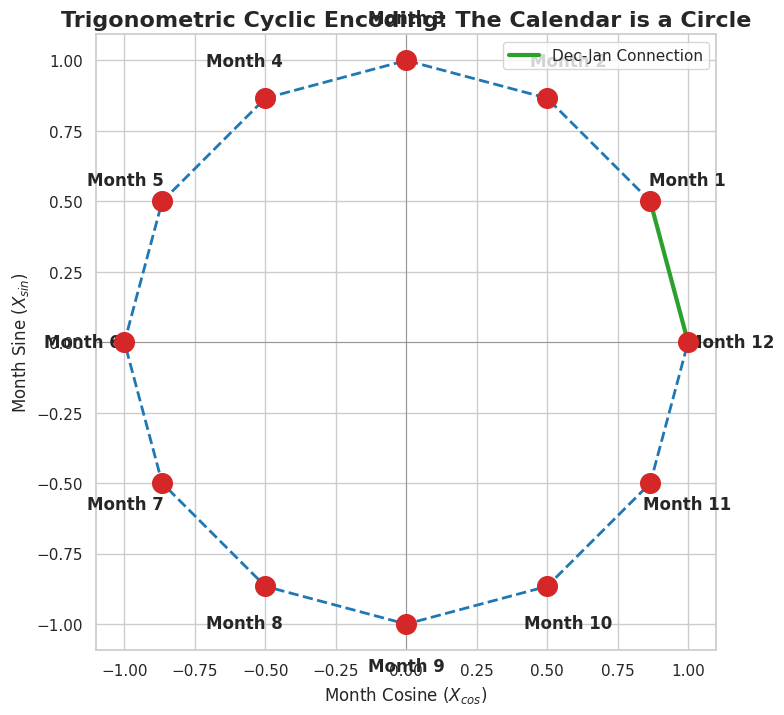

In [3]:
# 6. Matplotlib Visualization of Cyclic Encoding
plt.figure(figsize=(8, 8))

# Plot the 12 months on a 2D Cartesian plane using their Sin/Cos coordinates
months = np.arange(1, 13)
sin_vals = np.sin(2 * np.pi * months / 12)
cos_vals = np.cos(2 * np.pi * months / 12)

plt.scatter(cos_vals, sin_vals, color='#d62728', s=200, zorder=5)
plt.plot(cos_vals, sin_vals, color='#1f77b4', linestyle='--', linewidth=2, zorder=4)

# Connect December (Month 12) back to January (Month 1) to close the circle
plt.plot([cos_vals[-1], cos_vals[0]], [sin_vals[-1], sin_vals[0]], color='#2ca02c', linewidth=3, zorder=4, label='Dec-Jan Connection')

# Annotate the months
for m, s, c in zip(months, sin_vals, cos_vals):
    # Adjust text slightly outward for readability
    plt.text(c * 1.15, s * 1.15, f'Month {m}', fontsize=12, ha='center', va='center', fontweight='bold')

plt.title("Trigonometric Cyclic Encoding: The Calendar is a Circle", fontsize=16, fontweight='bold')
plt.xlabel("Month Cosine ($X_{cos}$)")
plt.ylabel("Month Sine ($X_{sin}$)")
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.axis('equal') # Ensure the circle is perfectly round
plt.legend(loc='upper right')
plt.show()

*(Insight: Look at the visual. The algorithm now plots December (Month 12) and January (Month 1) right next to each other in 2D space. The distance between them is exactly the same as the distance between Month 1 and Month 2. By splitting one column into two, we saved our Neural Networks from learning a massive, fake boundary!)*

## Real-World Use Case or Analogy:

Think of Temporal Feature Engineering like **Briefing a Bartender for a Shift**:

* **The Raw Timestamp**: You tell the bartender, "Your next shift is timestamp `1702684800`." The bartender has no idea what to prepare for. They are "time-blind."
* **Baseline Extraction**: You translate it. "Your shift is on a Friday, in December." Now they know to expect a busy night and holiday parties.
* **Proximity Engineering**: You add context. "It is exactly 2 days before New Year's Eve." Now they know to overstock the champagne, because the gravity of the approaching holiday changes consumer drinking habits days in advance.

You must act as the translator between the raw clock and the algorithm's logic.

---